In [1]:
# シグモイド関数
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [3]:
# シグモイド関数の微分（逆伝播）
def sigmoid_grad(x):
    y = sigmoid(x)
    return y * (1 - y)

In [ ]:
# シグモイド関数のオーバーフローを防ぐ書き方
# 入力xが正のときと負のときで数式を使い分ける処理をif文を使わずに書いたもの
# オーバーフロー：コンピュータはnp.exp(710)を越えたあたりで数値が大きすぎてinf（無限大）を表示してしまう
# 普通のシグモイド関数の弱点
# ➡ xに1000のような数値が入るとnp.exp(x)が巨大になってしまいオーバーフローが発生する
# オーバーフローは、np.exp(プラスの巨大な値)を計算することで発生する
# np.minimumで、入力がどれだけ大きくても小さいほうの0が選択されるので巨大な数値で計算が行われない

# 例：）x = 10のとき
# np.minimum(10, 0)：10と0を比べて小さいほうを選ぶ（0の方が小さい）
# つまり分子はnp.exp(0) = 1になる
# np.abs(10)：絶対値を表す
# つまり分母は 1 + np.exp(-10)
# 合体させると：1 / (1 + np.exp(-10))になって元のシグモイド関数と同じ式になる

# 例：）x = -10のとき
# np.minimum(-10, 0)：小さいほうを選ぶので結果は-10になる
# つまり分子はnp.exp(-10)
# np.abs(10)：絶対値なので10になる
# つまり分母は 1 + np.exp(-10)
# 合体させると：np.exp(-10) / (1 + np.exp(-10))のシグモイド関数の数式を変形したものと同じになる
def sigmoid(x):
    return np.exp(np.minimum(x, 0) / (1 + np.exp(-np.abs(x))))

In [ ]:
def np_log(x):
    return np.log(np.clip(a=x, a_min=1e-10, a_max=1e+10))

In [ ]:
def train_or(x, y, eps=1.0):
    global W_or, b_or

    batch_size = x.shape[0]

    # Affineレイヤ(matmul(x, W))をシグモイド関数に通して、予測値y_hatを出力
    y_hat = sigmoid(np.matmul(x, W_or) + b_or)  

    # 正解ラベルyと予測値y_hatを使って、交差エントロピーでペナルティを算出
    # .mean()で平均を取って全体の誤差（cost）を計算
    cost = (- y * np_log(y_hat) - (1 - y) * np_log(1 - y_hat)).mean() 

    # 複雑な計算が必要な交差エントロピーとシグモイド関数をすっ飛ばし、
    # 単純なy_hat(予測) - y(正解)で誤差を求められる
    delta = y_hat - y  

    # 重みの勾配を求める
    # delta(誤差)とx.Tを掛け、バッチサイズで割って平均を求める
    dW = np.matmul(x.T, delta) / batch_size  
    # バイアスの勾配を求める
    # バイアスは勾配をそのまま流すため、np.onesを掛けることで、全員分のdeltaを合計して平均を取る
    # という処理をスマートに書く
    db = np.matmul(np.ones(shape=(batch_size,)), delta) / batch_size  
    # 今の重みからさっき求めた勾配をひき算する
    # eps（学習率）を掛けて、歩幅を調整する
    W_or -= eps * dW
    b_or -= eps * db

    # 最終的な誤差を返す
    return cost

def valid_or(x, y):
    y_hat = sigmoid(np.matmul(x, W_or) + b_or)
    cost = (- y * np_log(y_hat) - (1 - y) * np_log(1 - y_hat)).mean()
    return cost, y_hat

In [ ]:
def softmax(x, axis=1):
    # x.max(axis=1)：それぞれのデータの中で一番大きい値を探す
    # keepdims=True：元のデータの形（行列の形）を維持したまま、最大値だけを抜き出すことができる
    x -= x.max(axis, keepdims=True)  
    # 指数関数に入れるxは、上のコードで最大値を引いて調整された、小さな数値になっている状態
    # ➡ オーバーフローを起こさずに計算できる
    # 小さくした値を指数関数でプラスにする（マイナスで確率は表現できないから）
    x_exp = np.exp(x) 

    # x_exp.sum()：全てのデータの指数関数を合計する
    # 個別の指数関数を全体の合計で割る
    return x_exp / x_exp.sum(axis, keepdims=True) 

In [2]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from keras.datasets import mnist

np.random.seed(34)

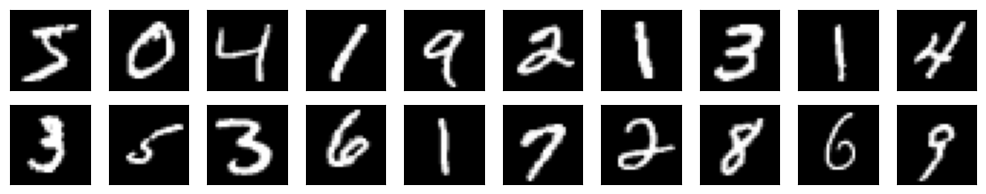

In [ ]:
import matplotlib.pyplot as plt

# 学習用データセットとテスト用データセットに分ける
(x_mnist_1, y_mnist_1), (x_mnist_2, y_mnist_2) = mnist.load_data()

# np.r_：Numpyが用意しているインデクサという特殊なオブジェクト
# ()で呼び出すのではなく、[]を使って配列を連結できる
# x_mnist：入力データ
# y_mnist：正解ラベル
x_mnist = np.r_[x_mnist_1, x_mnist_2]
y_mnist = np.r_[y_mnist_1, y_mnist_2]

fig = plt.figure(figsize=(10, 10))

for i in range(20):
    x = x_mnist[i]
    ax = fig.add_subplot(10, 10, i+1, xticks=[], yticks=[])
    ax.imshow(x, 'gray')
fig.tight_layout(rect=[0,0,1,0.96])
plt.show()